# Question 3: Size and Ingredient-frequency-controlled random control

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('recipe_ingredient_table.csv')
recipes = [g.tolist() for _, g in df.groupby('Recipe_ID')['Ingredient_Name']]
recipe_ids = sorted(df['Recipe_ID'].unique())
sizes = np.array([len(r) for r in recipes])
N = len(recipes)

freq = df['Ingredient_Name'].value_counts()
pool = freq.index.values
f = freq.values
print('Recipes:', N, '| Unique ingredients:', len(pool), '| Total ingredient occurrences:', f.sum())

rng = np.random.default_rng(42)
N_SETS = 10
size_axis = np.arange(1, sizes.max() + 1)

import os
OUT_DIR = 'outputs/Q3'
os.makedirs(OUT_DIR, exist_ok=True)

Recipes: 10168 | Unique ingredients: 10695 | Total ingredient occurrences: 138749


## Frequency-conserving random shuffle

In [2]:
starts = np.r_[0, np.cumsum(sizes)]
recipe_of_token = np.repeat(np.arange(N), sizes)
token_bag = np.repeat(np.arange(len(pool)), f)

def random_cuisine(rng):
    tok = rng.permutation(token_bag).tolist()
    while True:
        sets = [set(tok[starts[r]:starts[r + 1]]) for r in range(N)]
        bad = set()
        for r in range(N):
            if len(sets[r]) < sizes[r]:
                seen = set()
                for j in range(starts[r], starts[r + 1]):
                    if tok[j] in seen: bad.add(j)
                    else: seen.add(tok[j])
        if not bad:
            break
        for j in list(bad):
            r, x = recipe_of_token[j], tok[j]
            while True:
                k = int(rng.integers(len(tok)))
                r2, y = recipe_of_token[k], tok[k]
                if r2 == r or k in bad or x in sets[r2] or y in sets[r]:
                    continue
                tok[j], tok[k] = y, x
                sets[r].add(y); sets[r2].discard(y); sets[r2].add(x)
                break
    return [pool[tok[starts[r]:starts[r + 1]]].tolist() for r in range(N)]

## Create the 10 random cuisines

In [3]:
random_cuisines = [random_cuisine(rng) for _ in range(N_SETS)]

for i, cuisine in enumerate(random_cuisines, 1):
    assert all(len(set(r)) == len(r) for r in cuisine)
    assert (np.array([len(r) for r in cuisine]) == sizes).all()
    rf = pd.Series([ing for r in cuisine for ing in r]).value_counts().reindex(pool).fillna(0).astype(int).values
    assert (rf == f).all()
print('All 10 random cuisines: recipe sizes and ingredient frequencies match the original exactly.')

All 10 random cuisines: recipe sizes and ingredient frequencies match the original exactly.


## Q3(a): Recipe size distribution – original and random cuisines

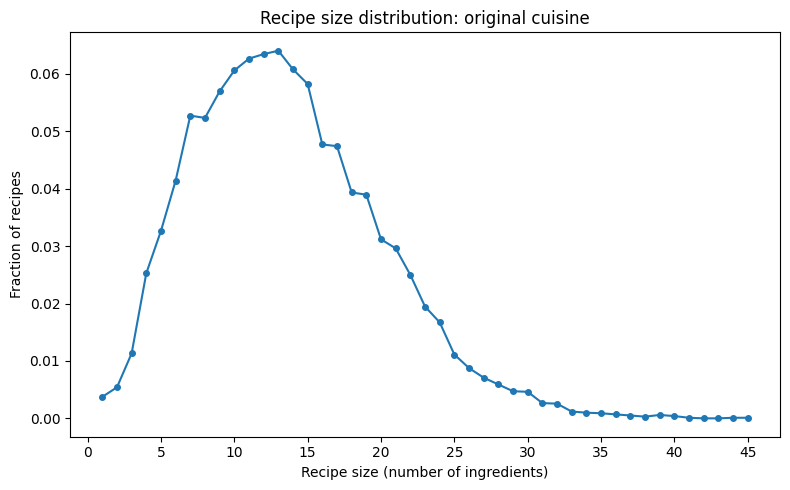

In [4]:
def size_distribution(size_array):
    counts = np.bincount(size_array, minlength=sizes.max() + 1)[1:]
    return counts / counts.sum()

orig_dist = size_distribution(sizes)
dist_rand = np.array([size_distribution(np.array([len(r) for r in c])) for c in random_cuisines])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(size_axis, orig_dist, color='tab:blue', marker='o', markersize=4, linewidth=1.5)
ax.set_xlabel('Recipe size (number of ingredients)'); ax.set_ylabel('Fraction of recipes')
ax.set_title('Recipe size distribution: original cuisine')
ax.set_xticks(np.arange(0, sizes.max() + 1, 5))
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, 'Q3a_original_recipe_size_distribution.png'), dpi=300); plt.show()

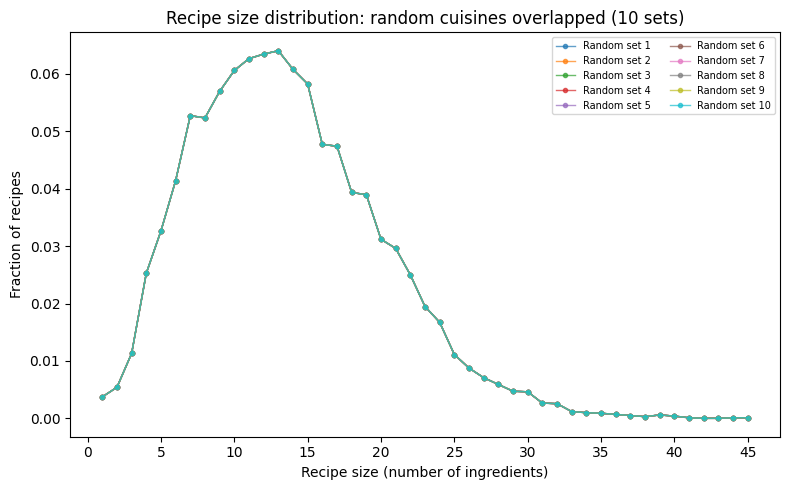

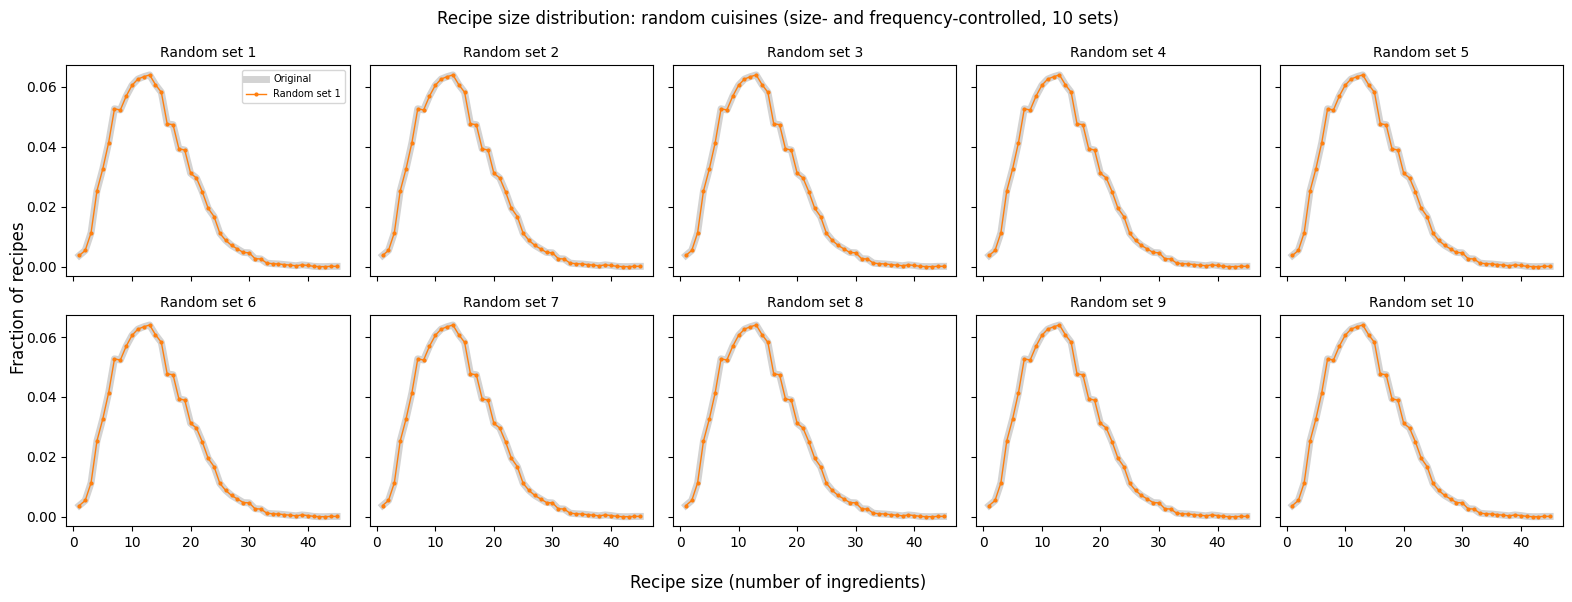

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.tab10(np.arange(N_SETS))
for i, d in enumerate(dist_rand):
    ax.plot(size_axis, d, color=colors[i], marker='o', markersize=3, linewidth=1, alpha=0.7, label=f'Random set {i+1}')
ax.set_xlabel('Recipe size (number of ingredients)'); ax.set_ylabel('Fraction of recipes')
ax.set_title('Recipe size distribution: random cuisines overlapped (10 sets)')
ax.set_xticks(np.arange(0, sizes.max() + 1, 5))
ax.legend(ncol=2, fontsize=7)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, 'Q3a_random_recipe_size_distribution_overlapped.png'), dpi=300); plt.show()

fig, axes = plt.subplots(2, 5, figsize=(16, 6), sharex=True, sharey=True)
for i, (ax, d) in enumerate(zip(axes.ravel(), dist_rand), 1):
    ax.plot(size_axis, orig_dist, color='lightgray', linewidth=5, label='Original')
    ax.plot(size_axis, d, color='tab:orange', marker='o', markersize=2, linewidth=1, label=f'Random set {i}')
    ax.set_title(f'Random set {i}', fontsize=10)
    ax.set_xticks(np.arange(0, sizes.max() + 1, 10))
axes[0, 0].legend(fontsize=7)
fig.supxlabel('Recipe size (number of ingredients)'); fig.supylabel('Fraction of recipes')
fig.suptitle('Recipe size distribution: random cuisines (size- and frequency-controlled, 10 sets)')
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, 'Q3a_random_recipe_size_distribution.png'), dpi=300); plt.show()

## Q3(b): Frequency–rank distribution – original and random cuisines

Ingredients are ranked by the number of recipes in which they occur (rank 1 = most frequent). Both axes are on a log scale.

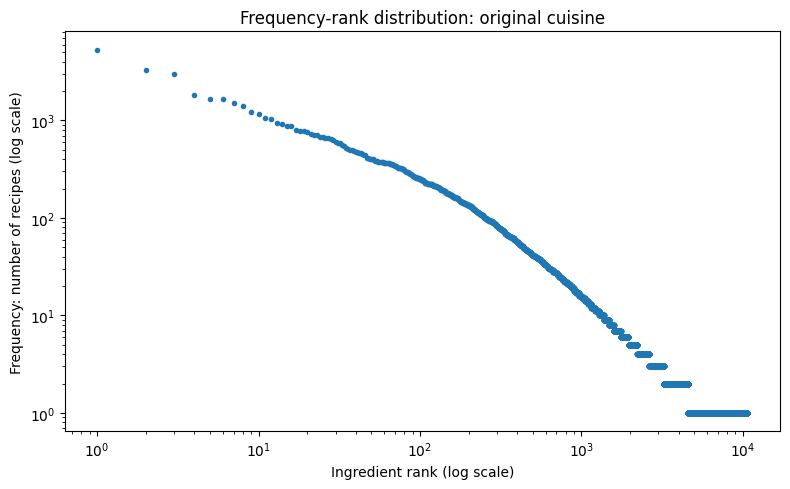

In [6]:
rank = np.arange(1, len(pool) + 1)
rand_freqs = np.array([pd.Series([ing for r in c for ing in r]).value_counts().reindex(pool).fillna(0).astype(int).values
                       for c in random_cuisines])
rand_freqs_sorted = -np.sort(-rand_freqs, axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(rank, f, 'o', markersize=3, color='tab:blue')
ax.set_xlabel('Ingredient rank (log scale)'); ax.set_ylabel('Frequency: number of recipes (log scale)')
ax.set_title('Frequency-rank distribution: original cuisine')
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, 'Q3b_original_frequency_rank.png'), dpi=300); plt.show()

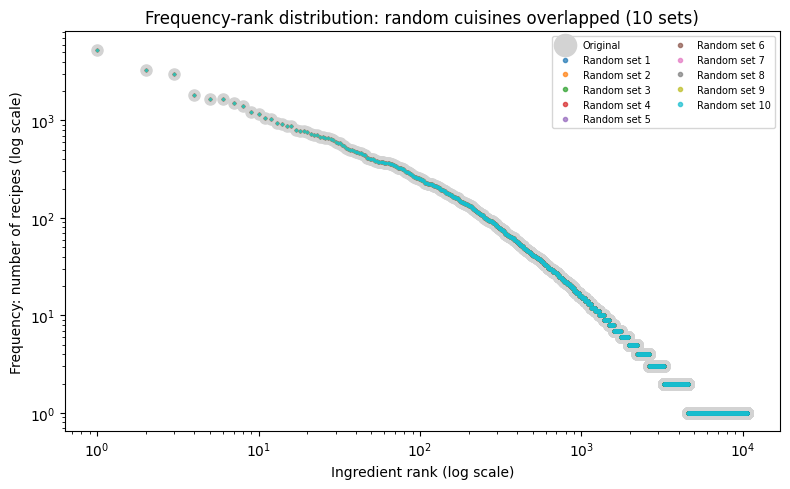

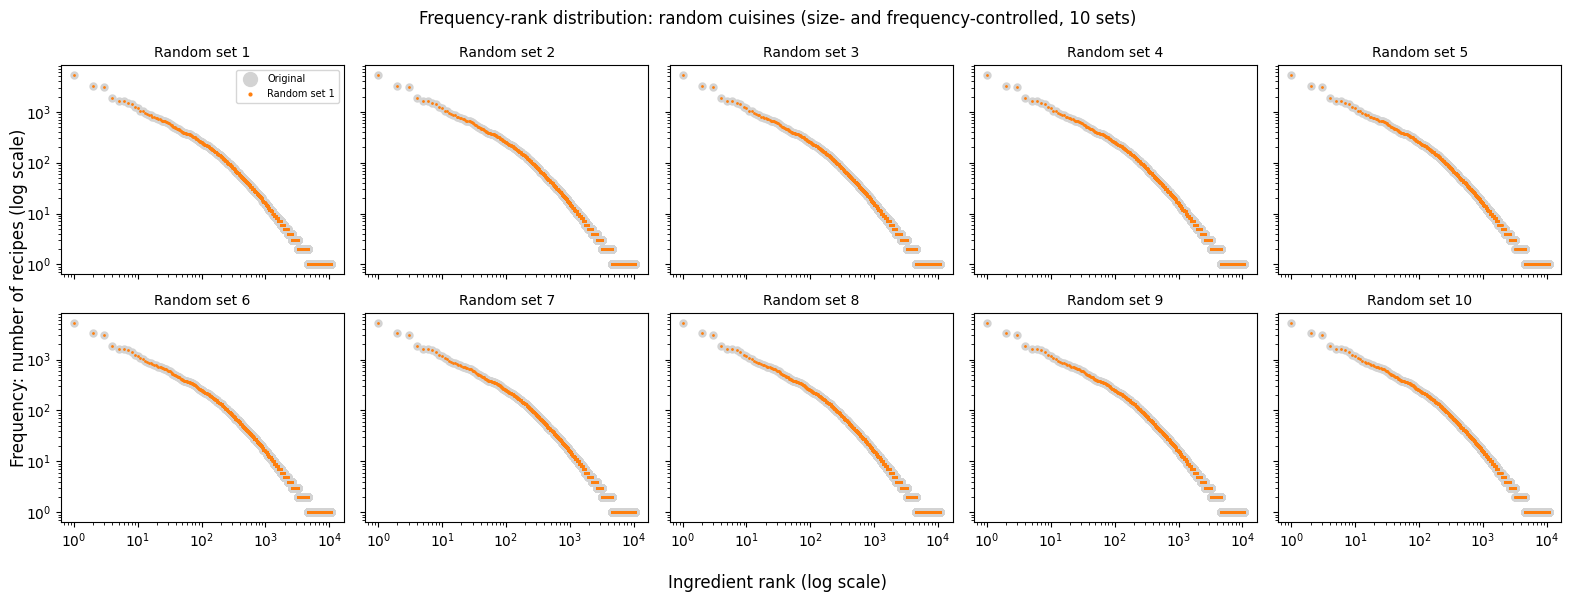

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.tab10(np.arange(N_SETS))
ax.loglog(rank, f, 'o', markersize=8, color='lightgray', label='Original')
for i, fr in enumerate(rand_freqs_sorted):
    ax.loglog(rank, fr, '.', markersize=3, color=colors[i], alpha=0.7, label=f'Random set {i+1}')
ax.set_xlabel('Ingredient rank (log scale)'); ax.set_ylabel('Frequency: number of recipes (log scale)')
ax.set_title('Frequency-rank distribution: random cuisines overlapped (10 sets)')
ax.legend(ncol=2, fontsize=7, markerscale=2)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, 'Q3b_random_frequency_rank_overlapped.png'), dpi=300); plt.show()

fig, axes = plt.subplots(2, 5, figsize=(16, 6), sharex=True, sharey=True)
for i, (ax, fr) in enumerate(zip(axes.ravel(), rand_freqs_sorted), 1):
    ax.loglog(rank, f, 'o', markersize=5, color='lightgray', label='Original')
    ax.loglog(rank, fr, '.', markersize=2, color='tab:orange', label=f'Random set {i}')
    ax.set_title(f'Random set {i}', fontsize=10)
axes[0, 0].legend(fontsize=7, markerscale=2)
fig.supxlabel('Ingredient rank (log scale)'); fig.supylabel('Frequency: number of recipes (log scale)')
fig.suptitle('Frequency-rank distribution: random cuisines (size- and frequency-controlled, 10 sets)')
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, 'Q3b_random_frequency_rank.png'), dpi=300); plt.show()